<h2 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1F3B4D; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Sentiment Analysis on Product Reviews
</h2>

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Load Data
</h6>

In [30]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Text Cleaning (Preprocessing)
</h6>

In [31]:
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  
    text = re.sub(r'<.*?>', '', text)  
    text = re.sub(r'[^a-zA-Z]', ' ', text)  
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

print(df[['clean_review']].head())

[nltk_data] Downloading package stopwords to C:\Users\Ahmed
[nltk_data]     Morad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                        clean_review
0  one reviewers mentioned watching oz episode ho...
1  wonderful little production filming technique ...
2  thought wonderful way spend time hot summer we...
3  basically family little boy jake thinks zombie...
4  petter mattei love time money visually stunnin...


<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Convert text to numbers (TF-IDF)
</h6>

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
                                max_features=5000,
                                ngram_range=(1,2)
                            )
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Data Spliting
</h6>

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                                        X, y,
                                                        test_size=0.2,
                                                        random_state=42,
                                                        stratify=y
                                                    )

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Logistic Regression Model
</h6>

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Evaluation
</h6>

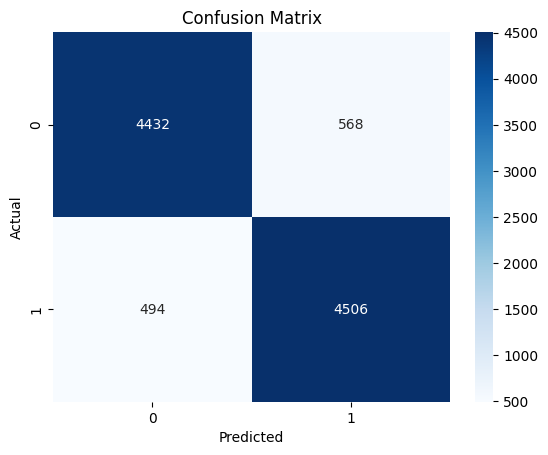

Accuracy: 0.8938
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [35]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

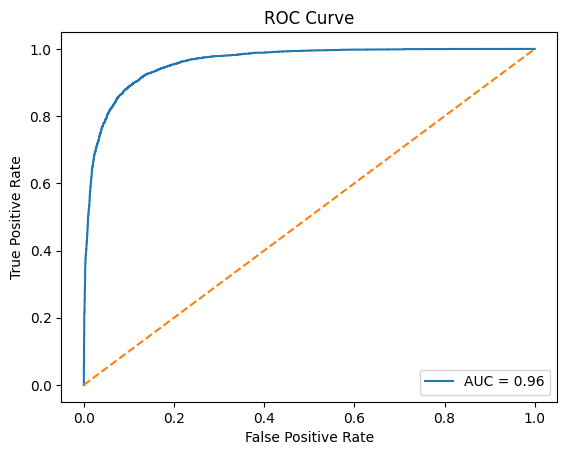

In [36]:
from sklearn.metrics import roc_curve, auc

y_prob =model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Naive Bayes
</h6>

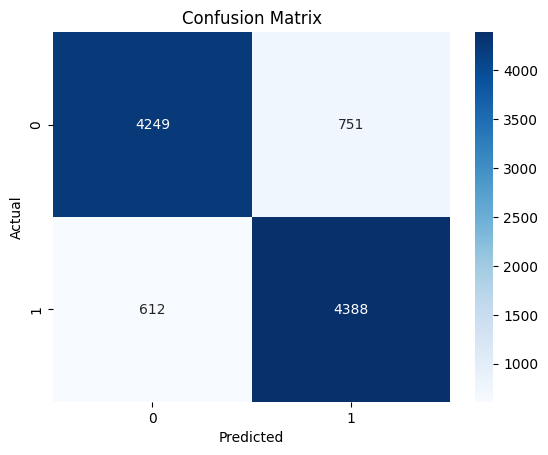

Naive Bayes Accuracy: 0.8637
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      5000
           1       0.85      0.88      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [37]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))   

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">
    Visualization
</h6>

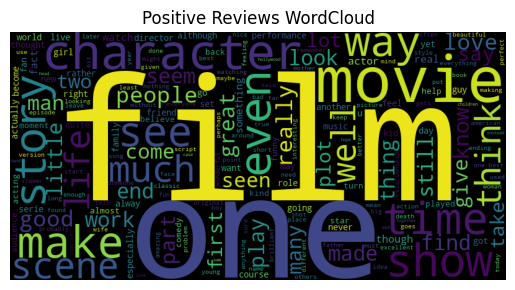

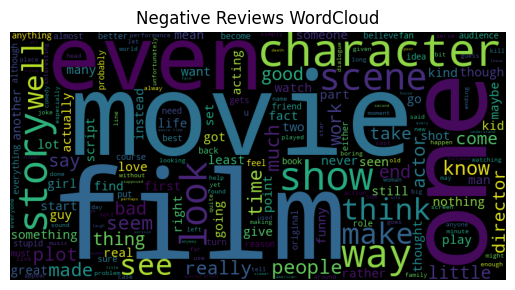

In [28]:
from wordcloud import WordCloud

positive_text = " ".join(df[df['sentiment']==1]['clean_review'])
negative_text = " ".join(df[df['sentiment']==0]['clean_review'])

# Positive
wc = WordCloud(width=800, height=400).generate(positive_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

# Negative
wc = WordCloud(width=800, height=400).generate(negative_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

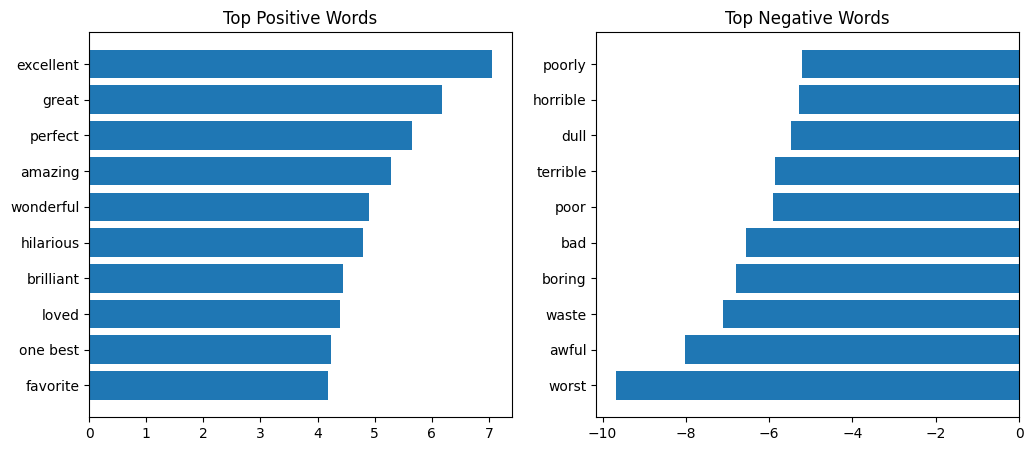

In [38]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = np.argsort(coef)[-10:]
top_negative = np.argsort(coef)[:10]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh([feature_names[i] for i in top_positive], coef[top_positive])
plt.title("Top Positive Words")

plt.subplot(1,2,2)
plt.barh([feature_names[i] for i in top_negative], coef[top_negative])
plt.title("Top Negative Words")

plt.show()